# Notebook 02 · Proxy Validation and Lag Screening

**Goal:** Rank candidate environmental regressors for the target variable (e.g., `absinc`) using Pearson correlation and lagged cross-correlation screening. Since the timeseries are already stationary, we focus solely on Pearson correlation to understand the best fit and determine optimal thermal inertia lags.

**Steps:**
1. **Load Aligned Data** — Load the dataset from Notebook 01.
2. **Initial Pearson Correlation** — Check immediate linear relationships between the target and proxies.
3. **Lag Screening** — Sweep through time lags to find the maximum cross-correlation (thermal memory).
4. **Feature Matrix Generation** — Align proxies with their optimal lags and save as a Parquet feature matrix for modeling.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath('..'))
from heritageshm.diagnostics import shift_and_correlate
from heritageshm.viz import apply_theme

apply_theme(context='notebook')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH   = "data/interim/aligned/st02_aligned_dataset.csv"
OUTPUT_PATH = "data/processed/feature_matrix.parquet"
FIG_PATH    = "outputs/figures/"

# ── Config ────────────────────────────────────────────────────────────────────
TARGET      = "absinc"
MAX_LAG_H   = 72          # maximum lag to screen (hours); 72h = 3 days thermal memory
LAG_STEP    = 1           # step in hours

## Step 1 · Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
df.index = pd.to_datetime(df.datetime)

# Drop non-proxy columns like charge or duplicate variables
EXCLUDE  = ["charge", "datetime", "temp", "hum", "oikolab_wind_speed (m/s)", "oikolab_wind_direction (deg)", "oikolab_total_cloud_cover (0-1)", TARGET]
proxies  = [c for c in df.columns if c not in EXCLUDE]

print(f"Loaded: {df.shape[0]} rows | {df.index[0]} → {df.index[-1]}")
print(f"Target : {TARGET}")
print(f"Proxies: {proxies}")
display(df[[TARGET] + proxies].describe().T)

Loaded: 57278 rows | 2018-07-25 23:00:00 → 2025-02-05 12:00:00
Target : absinc
Proxies: ['temperature (degC)', 'dewpoint_temperature (degC)', 'relative_humidity (0-1)', 'wetbulb_temperature (degC)', 'skin_temperature (degC)', 'urban_temperature (degC)', 'surface_solar_radiation (W/m^2)', 'surface_thermal_radiation (W/m^2)']


,count,mean,std,min,25%,50%,75%,max
absinc,39775.0,114.146001,52.153965,-53.45,84.8125,110.975,155.220833,231.80
temperature (degC),57278.0,13.619411,7.938618,-9.98,7.6100,12.860,19.330000,36.11
dewpoint_temperature (degC),57278.0,8.402467,6.144757,-14.63,4.1400,8.750,13.390000,22.10
relative_humidity (0-1),57278.0,0.735117,0.174166,0.18,0.6100,0.770,0.880000,1.00
wetbulb_temperature (degC),57278.0,10.452150,6.327203,-10.76,5.7000,10.380,15.710000,24.43
skin_temperature (degC),57278.0,13.464605,9.299911,-15.45,6.5300,12.520,19.530000,42.21
urban_temperature (degC),57278.0,14.425468,7.942013,-7.32,8.1500,13.560,20.750000,34.50
surface_solar_radiation (W/m^2),57278.0,171.345266,247.406748,0.00,0.0000,6.240,296.747500,945.36
surface_thermal_radiation (W/m^2),57278.0,318.925681,43.050782,198.22,288.4500,323.140,351.730000,431.26


### Visualizing Target vs. Proxies
Let's plot the target variable alongside each proxy to visually inspect their relationships over time.

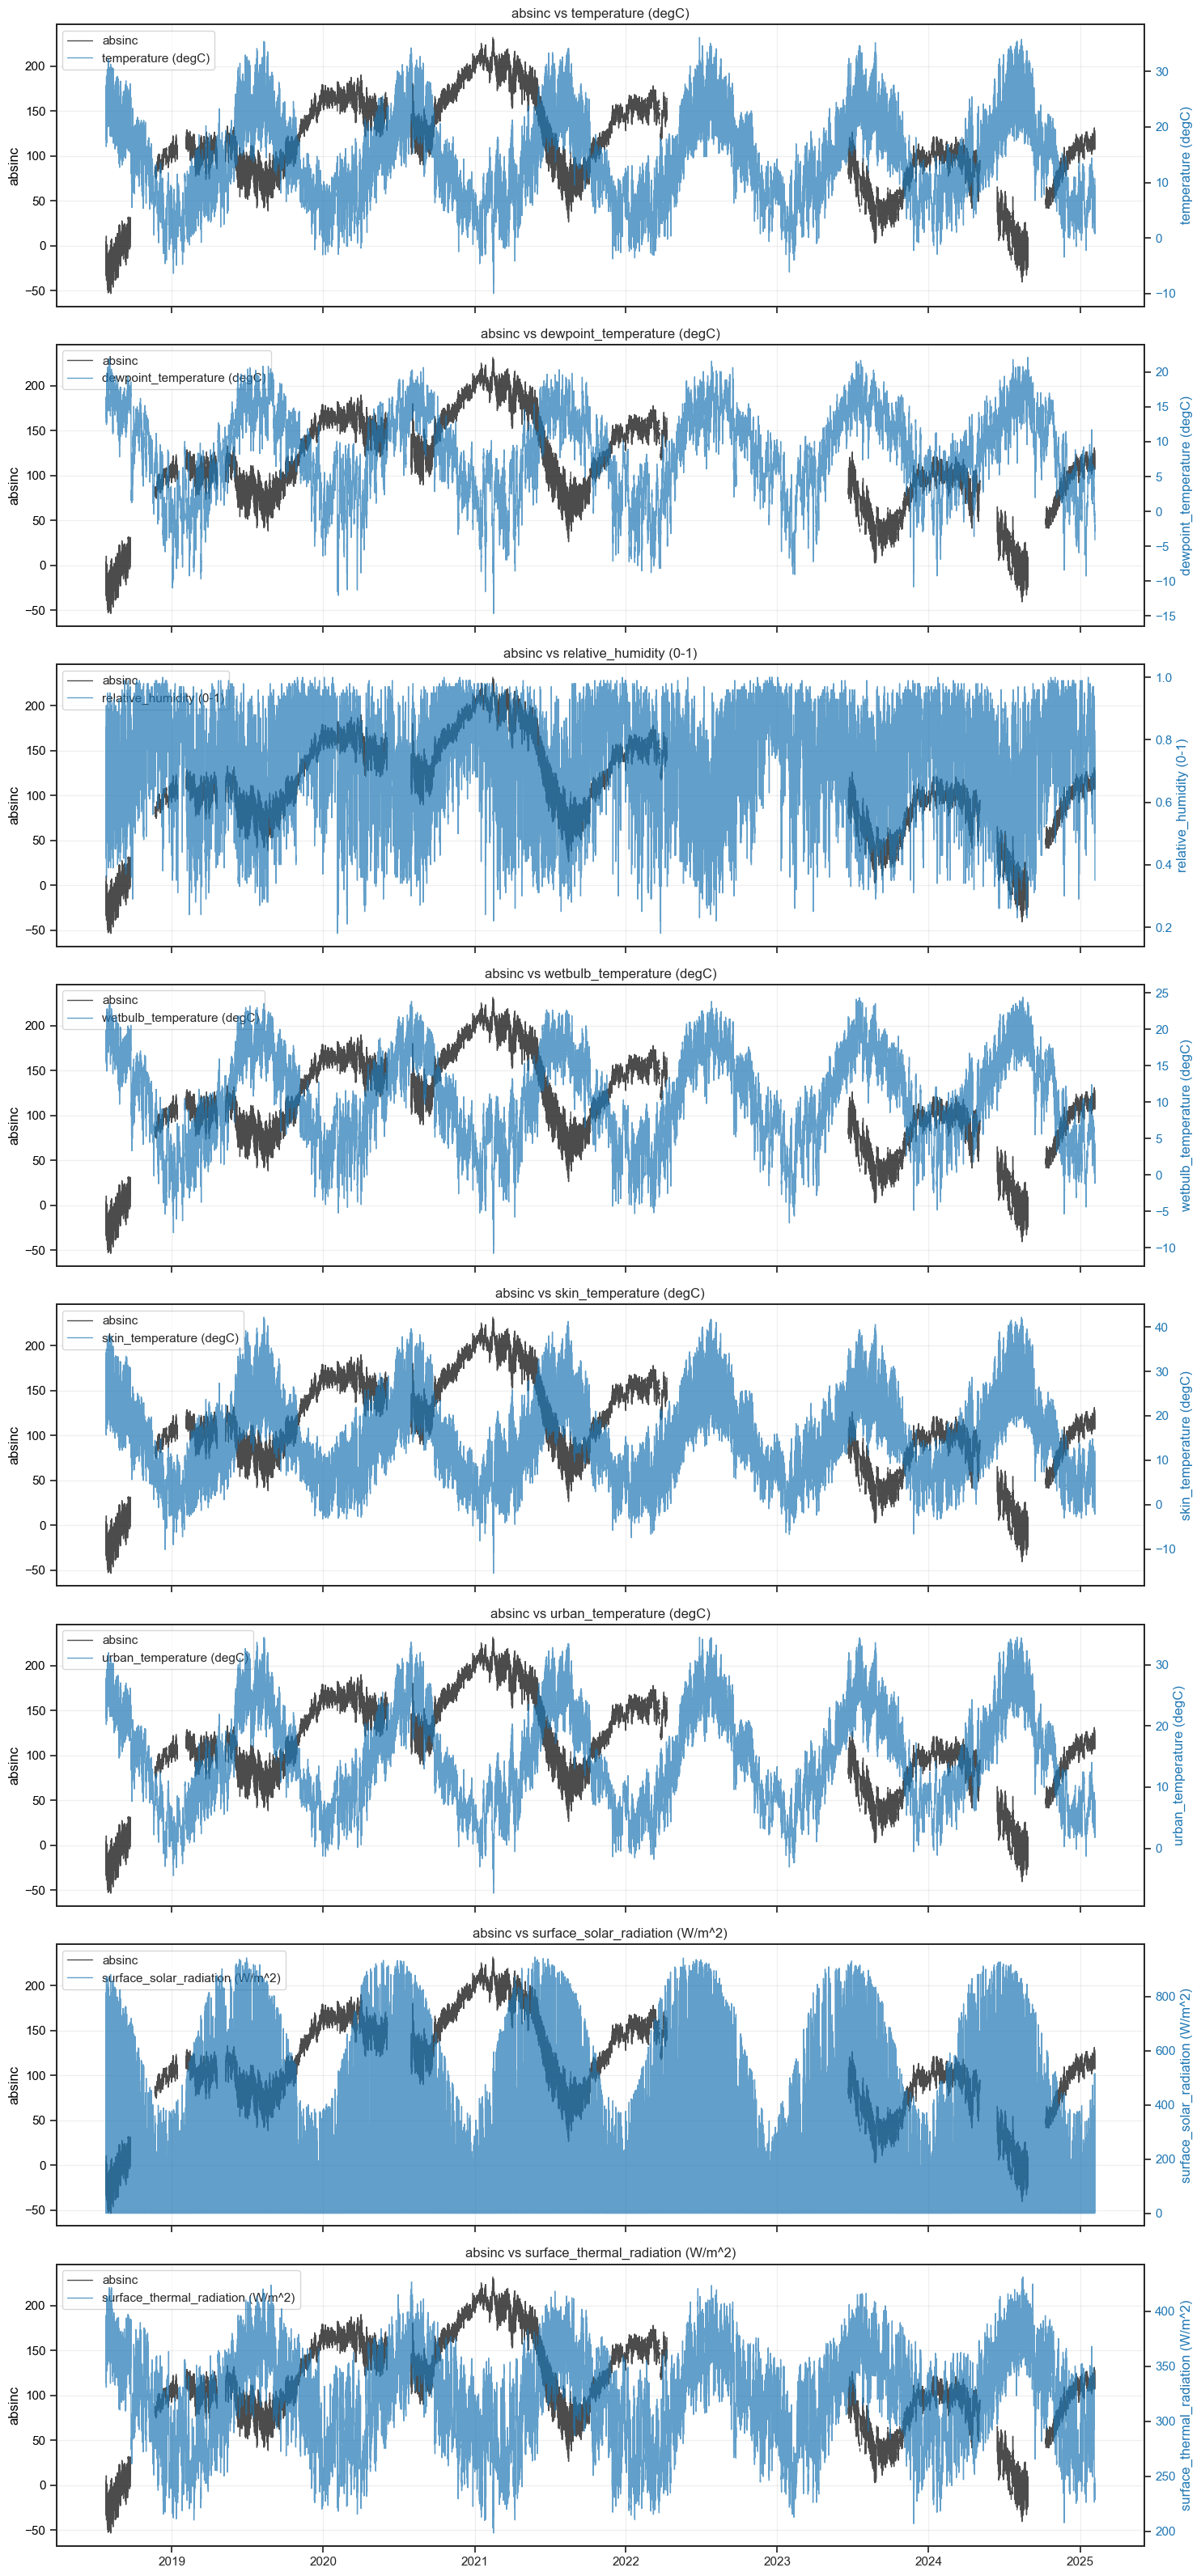

In [3]:
fig, axes = plt.subplots(len(proxies), 1, figsize=(15, 4 * len(proxies)), sharex=True)
if len(proxies) == 1:
    axes = [axes]

for ax, proxy in zip(axes, proxies):
    # Plot Target
    color_target = 'black'
    ax.plot(df.index, df[TARGET], label=TARGET, color=color_target, alpha=0.7, linewidth=1)
    ax.set_ylabel(TARGET, color=color_target)
    ax.tick_params(axis='y', labelcolor=color_target)
    
    # Plot Proxy on twin axis
    ax2 = ax.twinx()
    color_proxy = 'tab:blue'
    ax2.plot(df.index, df[proxy], label=proxy, color=color_proxy, alpha=0.7, linewidth=1)
    ax2.set_ylabel(proxy, color=color_proxy)
    ax2.tick_params(axis='y', labelcolor=color_proxy)
    
    ax.set_title(f"{TARGET} vs {proxy}")
    ax.grid(True, alpha=0.3)
    
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

## Step 2 · Initial Pearson Correlation
Since our timeseries are already stationary, we screen for immediate linear relationships.

In [4]:
# Calculate Pearson correlation for all proxies
initial_corrs = df[[TARGET] + proxies].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("--- Initial Pearson Correlation (Lag 0) ---")
print(initial_corrs)

--- Initial Pearson Correlation (Lag 0) ---
urban_temperature (degC)            -0.630012
wetbulb_temperature (degC)          -0.629756
temperature (degC)                  -0.625189
skin_temperature (degC)             -0.606793
dewpoint_temperature (degC)         -0.589018
surface_thermal_radiation (W/m^2)   -0.544568
relative_humidity (0-1)              0.261168
surface_solar_radiation (W/m^2)     -0.234983
Name: absinc, dtype: float64


## Step 3 · Lag Screening (Thermal Inertia)
Structural responses to environmental conditions (like temperature) are typically delayed due to thermal inertia. By screening shifted cross-correlations, we align the proxy optimally with the target.

temperature (degC): Optimal Lag = 0h, r = -0.625
dewpoint_temperature (degC): Optimal Lag = 1h, r = -0.589
relative_humidity (0-1): Optimal Lag = 0h, r = 0.261
wetbulb_temperature (degC): Optimal Lag = 0h, r = -0.630
skin_temperature (degC): Optimal Lag = 1h, r = -0.610
urban_temperature (degC): Optimal Lag = 0h, r = -0.630
surface_solar_radiation (W/m^2): Optimal Lag = 2h, r = -0.249
surface_thermal_radiation (W/m^2): Optimal Lag = 0h, r = -0.545


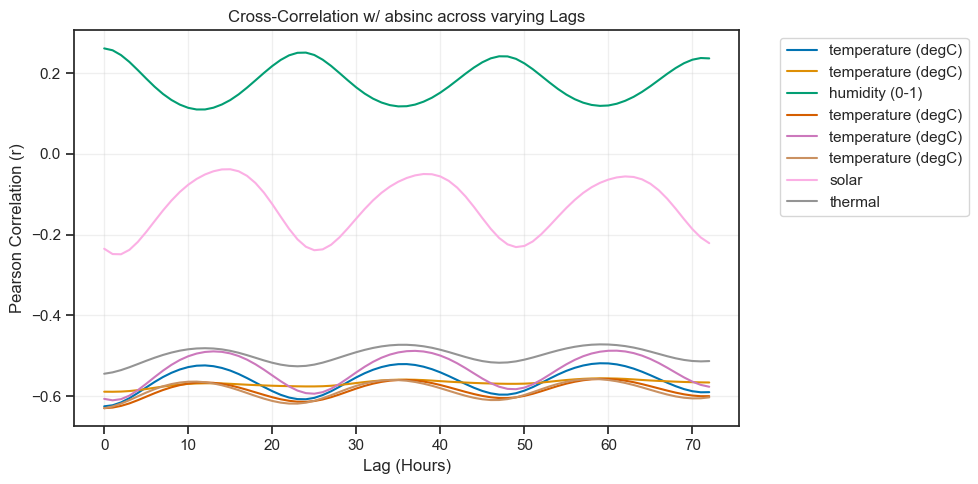

In [5]:
optimal_lags = {}
plt.figure(figsize=(10, 5))

for proxy in proxies:
    lags, corrs = shift_and_correlate(df, TARGET, proxy, MAX_LAG_H, LAG_STEP)
    
    # Find lag with maximum absolute correlation
    max_idx = np.argmax(np.abs(corrs))
    best_lag = lags[max_idx]
    best_corr = corrs[max_idx]
    
    optimal_lags[proxy] = best_lag
    
    print(f"{proxy}: Optimal Lag = {best_lag}h, r = {best_corr:.3f}")
    plt.plot(lags, corrs, label=proxy.split('_')[1] if '_' in proxy else proxy)

plt.title(f"Cross-Correlation w/ {TARGET} across varying Lags")
plt.xlabel("Lag (Hours)")
plt.ylabel("Pearson Correlation (r)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 · Assemble Feature Matrix
Shift the proxies by their optimal lags to construct the final dataset.

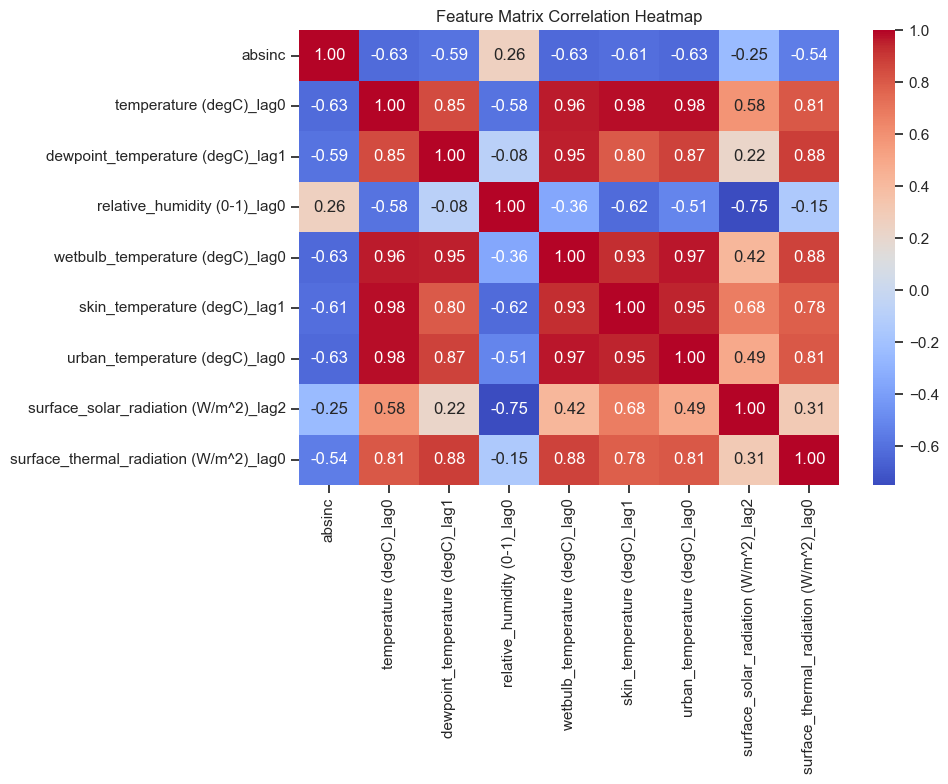

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [6]:
df_features = df[[TARGET]].copy()

for proxy, lag in optimal_lags.items():
    # Shift proxy forward by 'lag' hours 
    if lag == 0:
        df_features[f"{proxy}_lag0"] = df[proxy]
    else:
        df_features[f"{proxy}_lag{lag}"] = df[proxy].shift(lag)

# Plot correlation heatmap of the final features
plt.figure(figsize=(10, 8))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Matrix Correlation Heatmap")
plt.tight_layout()
plt.show()

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df_features.to_parquet(OUTPUT_PATH)
print(f"\nSaved feature matrix: {df_features.shape}")
print(f"Path: {OUTPUT_PATH}")